# Python deconvolution of all genes in the Xin Guo 2011 dataset, checking timing and concordance with Matlab and published dataset

In this notebook, we will test the deconvolve all of the genes in the Xin Guo 2011 dataset.

The goal is to verify that the deconvolution has been successfully ported from the matlab code base.

We will check the timing and compare the peak to trough values to the published paper dataset. 

In [12]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from src.model import Model
from src.config import load_xg_gene_expression_config

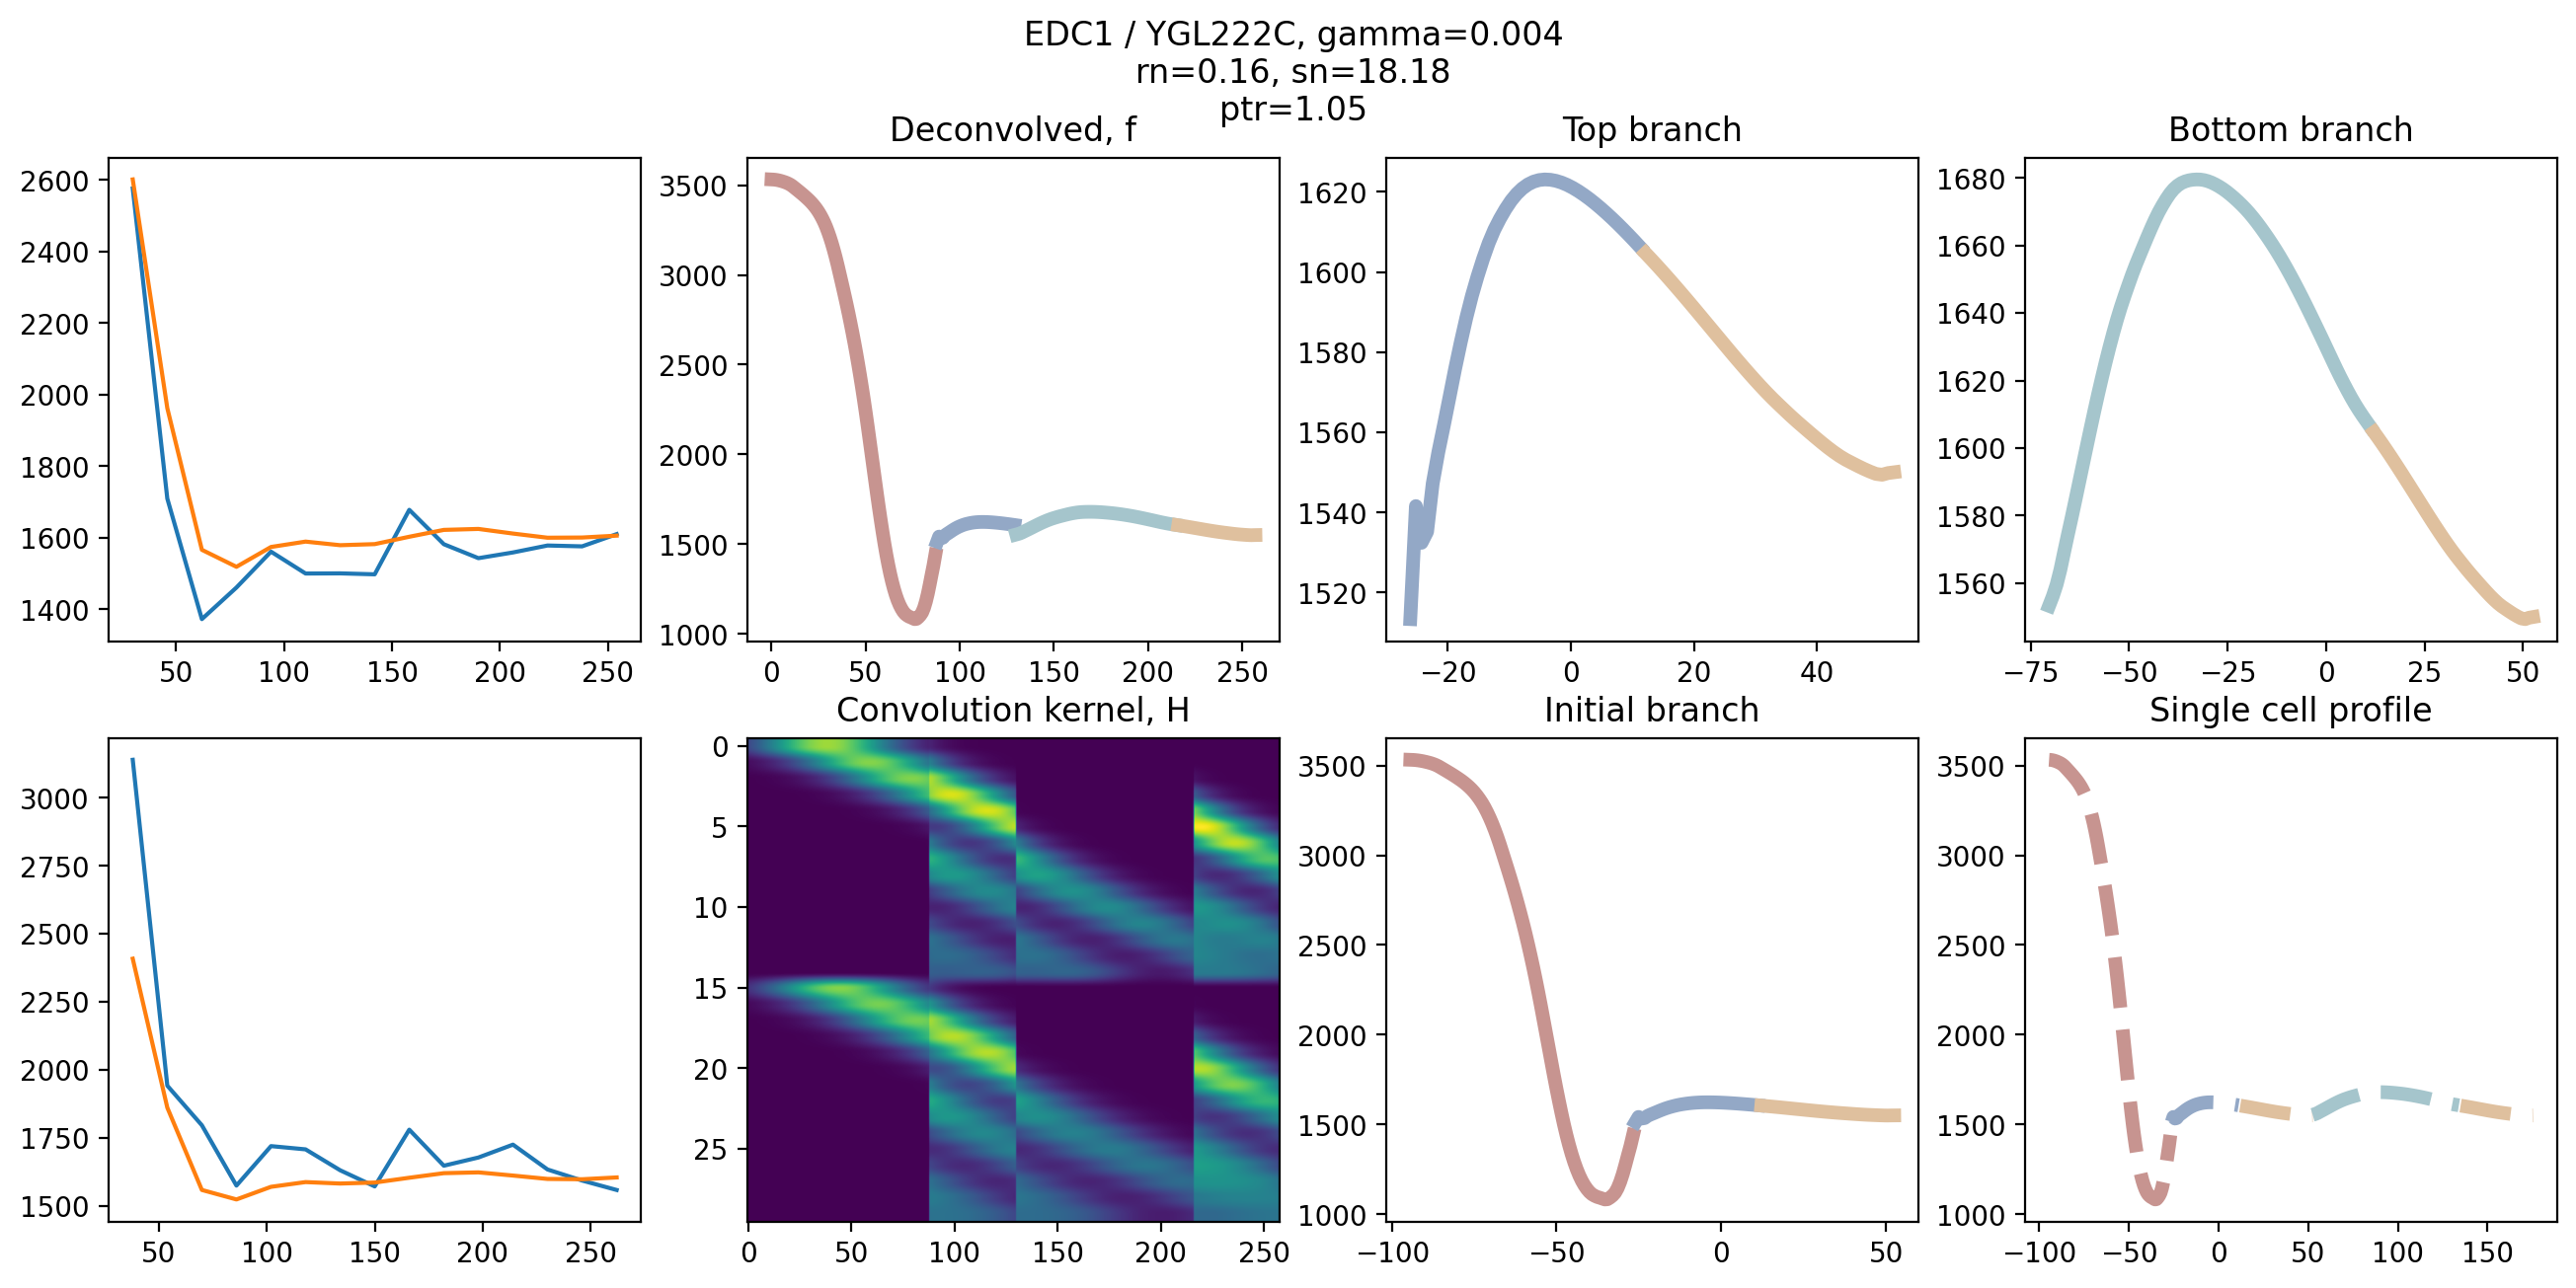

In [218]:
model = deconvolve_gene(gene_or_orfname='EDC1', plot=True)

In [247]:
from src.model import deconvolve_all_genes

# Initialize configuration and model
config = load_xg_gene_expression_config()
gene_fs_df, gene_meta_df = deconvolve_all_genes(config, 'output/xg')


Deconvolving 5670 genes...
   1/5670 - 00:00:00.90
   101/5670 - 00:01:35.94
   201/5670 - 00:03:10.95
Error with orf: YDL038C, Skipping...
   301/5670 - 00:04:45.06
   401/5670 - 00:06:20.16
Error with orf: YHL009W-B, Skipping...
   501/5670 - 00:07:53.81
   601/5670 - 00:09:28.96
   701/5670 - 00:11:05.92
   801/5670 - 00:12:41.85
   901/5670 - 00:14:16.88
   1001/5670 - 00:15:51.18
   1101/5670 - 00:17:27.05
   1201/5670 - 00:19:02.03
Error with orf: YHL009W-A, Skipping...
   1301/5670 - 00:20:35.03
   1401/5670 - 00:22:07.98
   1501/5670 - 00:23:40.80
   1601/5670 - 00:25:13.81
   1701/5670 - 00:26:48.26
   1801/5670 - 00:28:21.68
   1901/5670 - 00:29:55.35
Error with orf: YIL082W-A, Skipping...
   2001/5670 - 00:31:28.28
   2101/5670 - 00:33:01.77
   2201/5670 - 00:34:35.62
   2301/5670 - 00:36:08.70
Error with orf: YBL005W-A, Skipping...
   2401/5670 - 00:37:41.50
Error with orf: YDR316W-B, Skipping...
   2501/5670 - 00:39:14.32
   2601/5670 - 00:40:48.33
   2701/5670 - 00:42:22.

In [253]:
gene_meta_df = gene_meta_df.sort_values('ptr').dropna().join(genes[['gene']])
gene_meta_df

,cptr,dptr,ptr,rn,sn,gene
orf_name,,,,,,
YDR342C,1.000156,1.002359,1.000890,0.009590,4.592420,HXT7
YGL076C,1.000126,1.002463,1.000904,0.008130,4.950590,RPL7A
YDR064W,1.000571,1.002748,1.001296,0.002566,5.064115,RPS13
YDR194W-A,1.000330,1.003444,1.001367,0.162308,4.926661,YDR194W-A
YLR167W,1.000143,1.004501,1.001593,0.005378,4.530388,RPS31
...,...,...,...,...,...,...
YLR286C,1736.478675,35240.047858,4736.510083,0.999650,38.949528,CTS1
YMR076C,5778.123355,3398.041913,4840.989232,0.476533,58.732040,PDS5
YIL140W,7993.542889,6175.524395,7334.730371,0.364842,56.812072,AXL2


In [254]:
gene_meta_df[gene_meta_df.gene == 'CLN2']

,cptr,dptr,ptr,rn,sn,gene
orf_name,,,,,,
YPL256C,4949.440663,4274.571639,4713.40706,0.853722,58.897744,CLN2


In [265]:
gene_table_path = '/Users/trung/Research/cell-cycle/data/'\
                  'dataset_from_deconv_web/gene_associated.tsv'
gene_table = pd.read_csv(gene_table_path, sep='\t');
gene_table = gene_table.set_index('Systematic Name')
gene_table = gene_table[[gene_table.columns[4]]]
gene_table.columns = ['published_ptr']
gene_table.head(2)


,published_ptr
Systematic Name,
YKR013W,14716.721
YIL140W,7425.072


In [266]:
gene_meta_df.join(gene_table)



,cptr,dptr,ptr,rn,sn,gene,published_ptr
orf_name,,,,,,,
YDR342C,1.000156,1.002359,1.000890,0.009590,4.592420,HXT7,1.080
YGL076C,1.000126,1.002463,1.000904,0.008130,4.950590,RPL7A,1.001
YDR064W,1.000571,1.002748,1.001296,0.002566,5.064115,RPS13,1.001
YDR194W-A,1.000330,1.003444,1.001367,0.162308,4.926661,YDR194W-A,1.001
YLR167W,1.000143,1.004501,1.001593,0.005378,4.530388,RPS31,1.002
...,...,...,...,...,...,...,...
YLR286C,1736.478675,35240.047858,4736.510083,0.999650,38.949528,CTS1,4814.042
YMR076C,5778.123355,3398.041913,4840.989232,0.476533,58.732040,PDS5,4929.320
YIL140W,7993.542889,6175.524395,7334.730371,0.364842,56.812072,AXL2,7425.072


In [337]:
from src.config import load_xg_gene_expression_config

config = load_xg_gene_expression_config()
model = Model(config, 'CLN2')

In [338]:
model.deconvolve()

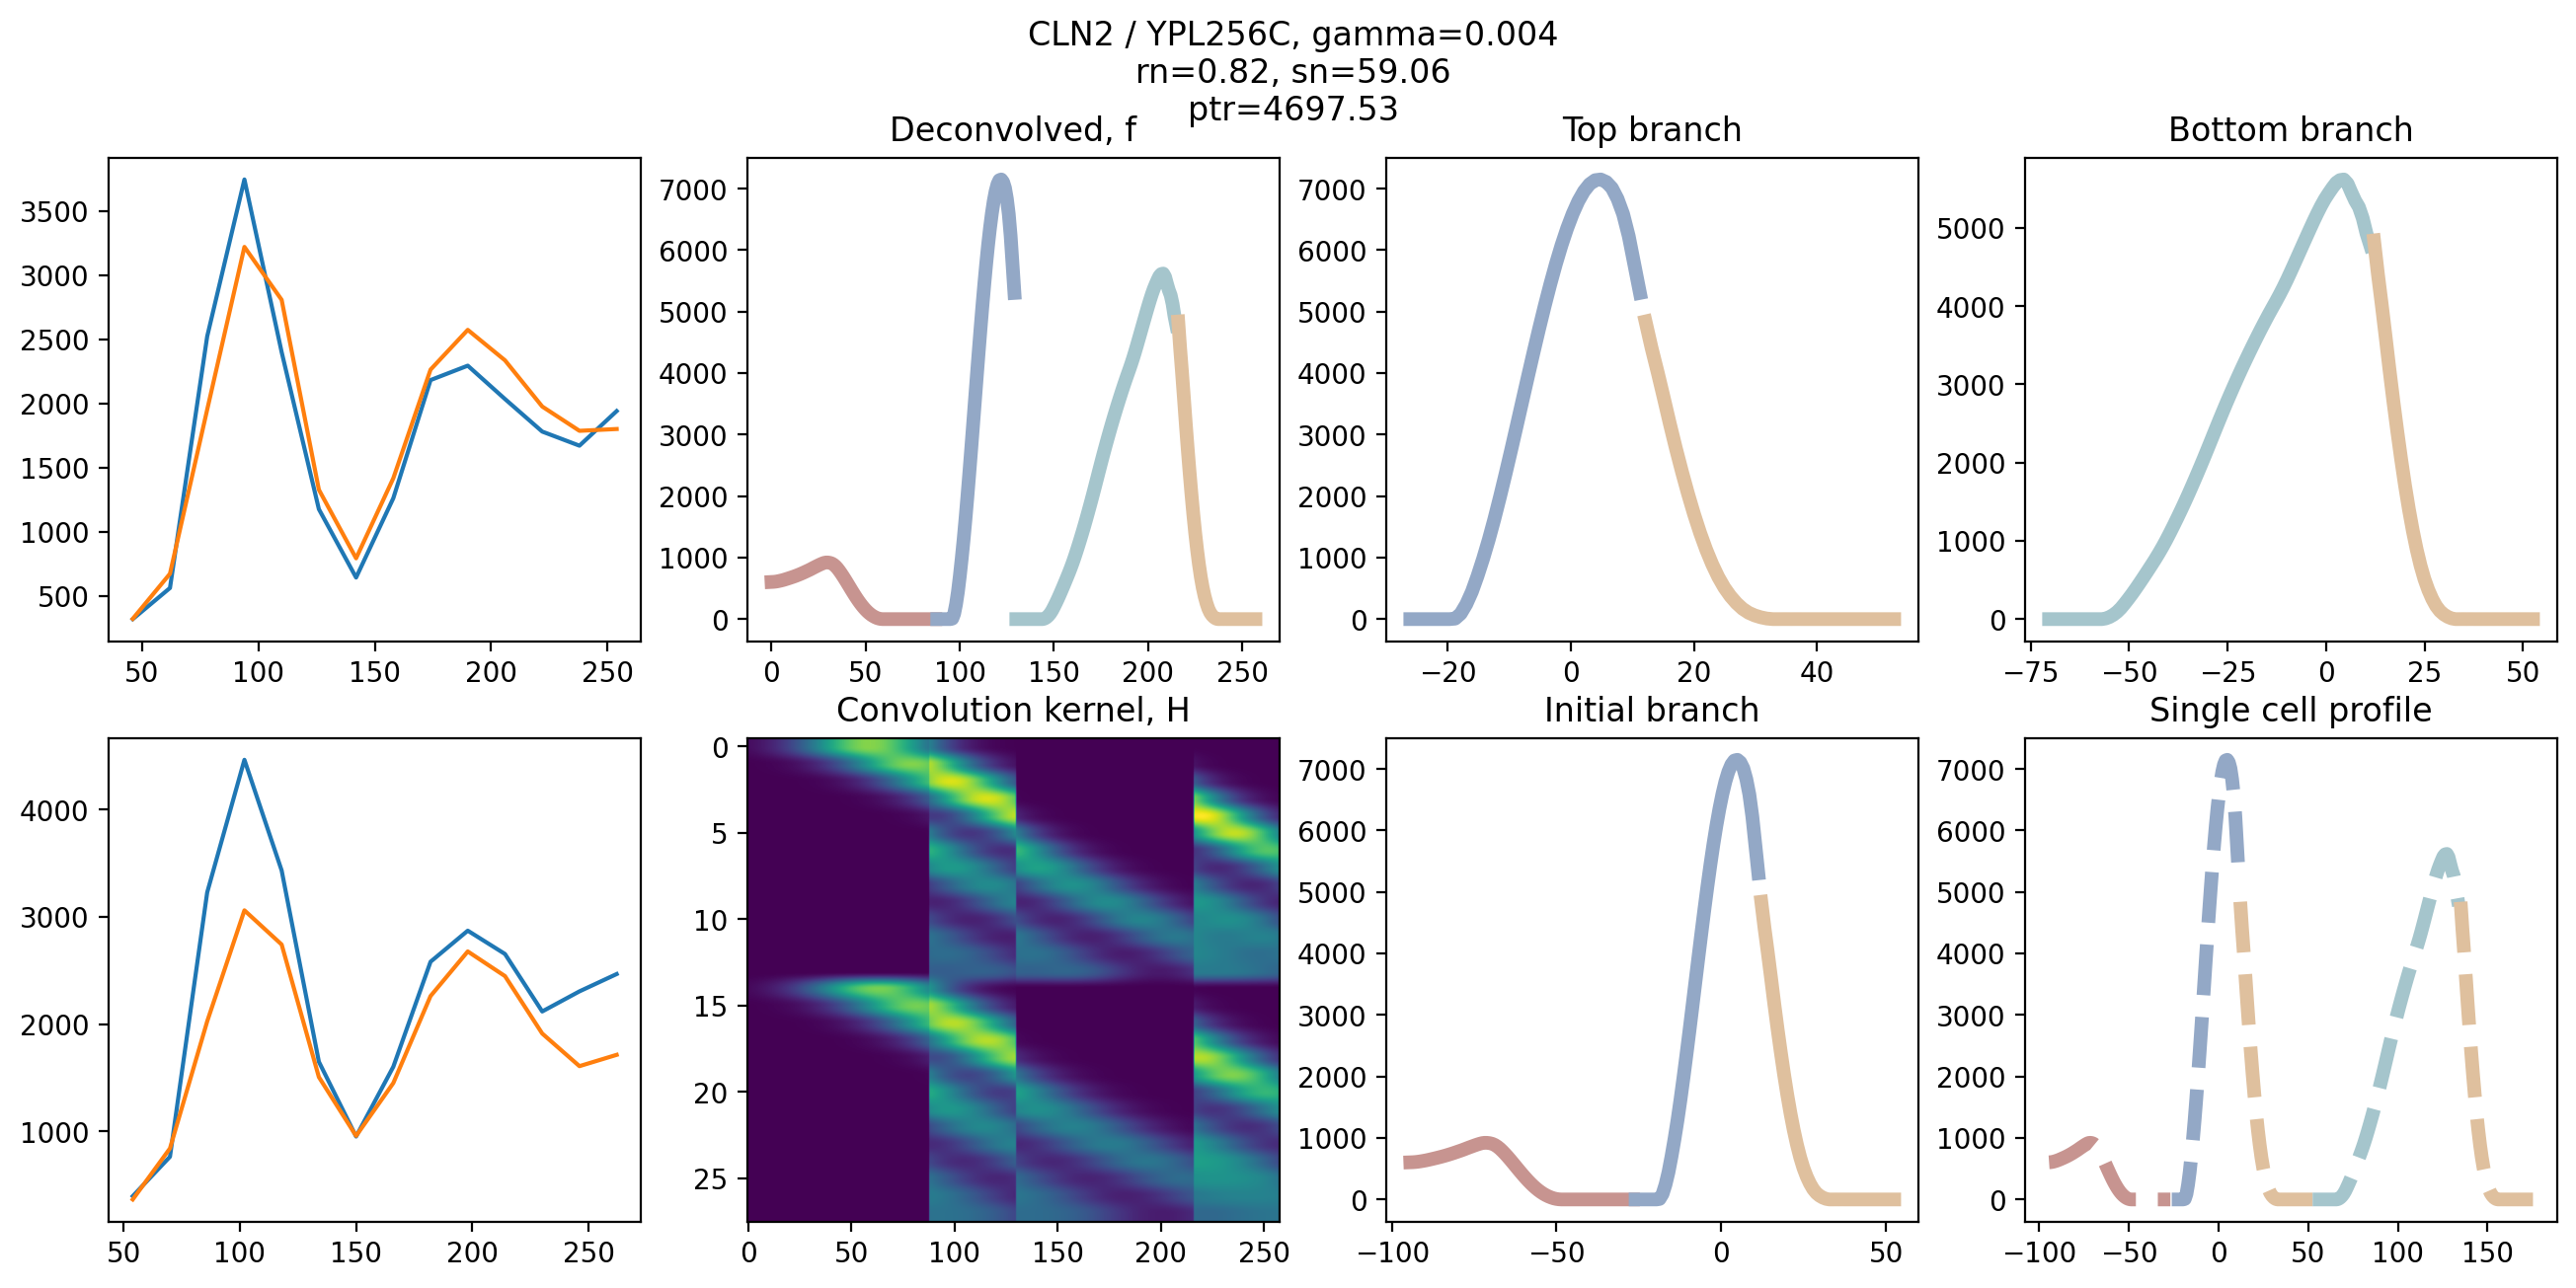

In [339]:
model.plot_deconvolved_gene()